In [2]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl

#### Load the excel Data into a DataFrame

In [5]:
marketing = pd.read_excel(r"C:\Users\LENOVO YOGA X390\Desktop\PyData_Capstone_Project\Data\Task1 Data.xlsx")

print(marketing.head()) # firts 5 rows of dataset

        Date                             CampaignID Campaign Code  \
0 2022-01-01  FW20-Run|PO203366|FB|DE|Consideration          FW20   
1 2022-01-02  FW20-Run|PO559150|FB|DE|Consideration          FW20   
2 2022-01-03      FW20-Run|PO424678|FB|DE|Awareness          FW20   
3 2022-01-04      FW20-Run|PO756200|FB|DE|Awareness          FW20   
4 2022-01-05     FW20-Run|PO456943|FB|DE|Conversion          FW20   

  Campaign Name PO Number Channel Country Code         Tactic  Media Cost  \
0           Run  PO203366      FB           DE  Consideration      441.17   
1           Run  PO559150      FB           DE  Consideration      445.27   
2           Run  PO424678      FB           DE      Awareness      324.52   
3           Run  PO756200      FB           DE      Awareness      412.02   
4           Run  PO456943      FB           DE     Conversion      911.34   

   Impressions  Clicks  Conversions  
0        53964     560         2364  
1        60733     521         2325  
2       

In [6]:
marketing.dtypes # column data types

Date             datetime64[us]
CampaignID                  str
Campaign Code               str
Campaign Name               str
PO Number                   str
Channel                     str
Country Code                str
Tactic                      str
Media Cost              float64
Impressions               int64
Clicks                    int64
Conversions               int64
dtype: object

In [7]:
print(marketing.shape) # rows and columns

(517, 12)


In [8]:
marketing.tail()

,Date,CampaignID,Campaign Code,Campaign Name,PO Number,Channel,Country Code,Tactic,Media Cost,Impressions,Clicks,Conversions
512,2023-05-28,FW20-Women|PO901403|IG|UK|Awareness,FW20,Women,PO901403,IG,UK,Awareness,125.64,48611,64,11021
513,2023-05-29,FW20-Women|PO790990|IG|UK|Conversion,FW20,Women,PO790990,IG,UK,Conversion,184.01,30013,171,598
514,2023-05-30,FW20-Women|PO249804|IG|UK|Conversion,FW20,Women,PO249804,IG,UK,Conversion,164.85,29307,174,983
515,2023-05-31,FW20-Women|PO902182|IG|DE|Conversion,FW20,Women,PO902182,IG,DE,Conversion,129.16,21332,132,464
516,2023-06-01,FW20-Women|PO651961|IG|DE|Conversion,FW20,Women,PO651961,IG,DE,Conversion,150.31,19057,134,884


In [9]:
print(marketing.shape) # rows and columns

(517, 12)


In [10]:
# The source data has clicks and conversions swapped, thus renamiming the columns
# for better understanding
# Evidence : 'Conversions' > 'Clicks' in every row is impossible for real conversions.
marketing =marketing.rename(columns={
    'Clicks': 'Conversions',   # was mislabelled as Clicks, but actually reps conversions
    'Conversions': 'Clicks'  # was mislabelled as Conversions
})

In [11]:
# Create month column and drop partial June row in the dataset.
# dt.to_period('M') strips the day from each date, giving a new column with just year and month best for monthly analysis.

marketing['Month'] = marketing['Date'].dt.to_period('M')

# The dataset ends on June 1,a single row
# Keeping it would show false output meaning for the whole dataset, thus dropping it.
marketing = marketing[marketing['Month'] != '2023-06'].copy()

print(f" Rows loaded:{len(marketing)}")
print(f"Date range : {marketing['Date'].min().date()} → {marketing['Date'].max().date()}")
print (f"Columns : {marketing.columns.tolist()}")
print(f"{(marketing['Conversions'] > marketing['Clicks']).sum()} rows (should be 0\n")


 Rows loaded:516
Date range : 2022-01-01 → 2023-05-31
Columns : ['Date', 'CampaignID', 'Campaign Code', 'Campaign Name', 'PO Number', 'Channel', 'Country Code', 'Tactic', 'Media Cost', 'Impressions', 'Conversions', 'Clicks', 'Month']
0 rows (should be 0



In [12]:
# Split the campaignID column to derive necessary data
new_col = ["Campaign Code-Name", "PO Number", "Channel", "Country Code", "Tactic"]
marketing[new_col] = marketing["CampaignID"].str.split("|", expand=True)
marketing[["Campaign Mode", "Campaign Name"]] = marketing["Campaign Code-Name"].str.split("-", expand=True)

# Drop the unnecessary columns
marketing.drop(columns = ['CampaignID', 'Campaign Code-Name'], inplace=True)

In [13]:
print(marketing.info())

<class 'pandas.DataFrame'>
RangeIndex: 516 entries, 0 to 515
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           516 non-null    datetime64[us]
 1   Campaign Code  516 non-null    str           
 2   Campaign Name  516 non-null    str           
 3   PO Number      516 non-null    str           
 4   Channel        516 non-null    str           
 5   Country Code   516 non-null    str           
 6   Tactic         516 non-null    str           
 7   Media Cost     516 non-null    float64       
 8   Impressions    516 non-null    int64         
 9   Conversions    516 non-null    int64         
 10  Clicks         516 non-null    int64         
 11  Month          516 non-null    period[M]     
 12  Campaign Mode  516 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(3), period[M](1), str(7)
memory usage: 52.5 KB
None


In [14]:
print("Number of rows and columns: ", marketing.shape)
print("Number of duplicated rows: ", marketing.duplicated().sum())
marketing.dtypes


Number of rows and columns:  (516, 13)
Number of duplicated rows:  0


Date             datetime64[us]
Campaign Code               str
Campaign Name               str
PO Number                   str
Channel                     str
Country Code                str
Tactic                      str
Media Cost              float64
Impressions               int64
Conversions               int64
Clicks                    int64
Month                 period[M]
Campaign Mode               str
dtype: object

Question 1. Which campaign had the highest click-through rate?

- CTR = Clicks /  Impressions. Higher means more people clicked after seeing the ad.

In [15]:
# Save the cleaned dataset
marketing.to_csv('cleaned_Round2_TaskforGeneration.csv', index=True)


In [16]:
marketing = pd.read_csv(r"C:\Users\LENOVO YOGA X390\Desktop\PyData_Capstone_Project\cleaned_Round2_TaskforGeneration.csv")

In [17]:

marketing[['Clicks', 'Impressions']].sum()

Clicks          5474754
Impressions    55015428
dtype: int64

In [18]:
# Show all campaigns in the dataset			
marketing['Campaign Name'].unique()			


<StringArray>
['Run', 'Women']
Length: 2, dtype: str

In [19]:
# groupby Campaign Name for total clicks and impressions per campaign before dividing for CTR
q1 = (
    marketing.groupby('Campaign Name')
    .agg(total_clicks = ('Clicks', 'sum'),
        total_impressions = ('Impressions', 'sum'))
)

q1['CTR'] = q1['total_clicks'] / q1['total_impressions'] * 100   # as percentage
q1 = q1.sort_values('CTR', ascending=False)
winner = q1['CTR'].idxmax()

print ("="*50)
print("Click-Through Rate by Campaign")
print ("="*50)
print(q1[['CTR']].round(2).to_string())
print(f"The campaign with the highest CTR is: {winner}")
print ("="*50)
print(f"""The campaign '{winner}' has the highest click-through rate at {q1.loc[winner, 'CTR']: .2f}%", indicating it is the most effective in engaging users.
It outperforms the Women campaign by this margin: {q1['CTR'].max() - q1['CTR'].min(): .2f}%
That means about 1 in every {int(100/q1.loc[winner, 'CTR'])} people who saw the ad and clicked.
""")
print ("="*50)

Click-Through Rate by Campaign
                 CTR
Campaign Name       
Run            11.21
Women           5.30
The campaign with the highest CTR is: Run
The campaign 'Run' has the highest click-through rate at  11.21%", indicating it is the most effective in engaging users.
It outperforms the Women campaign by this margin:  5.91%
That means about 1 in every 8 people who saw the ad and clicked.



Insight:
- The Campaign with the highest CTR is `Run`.

- It ouperforms the `women` campaign 

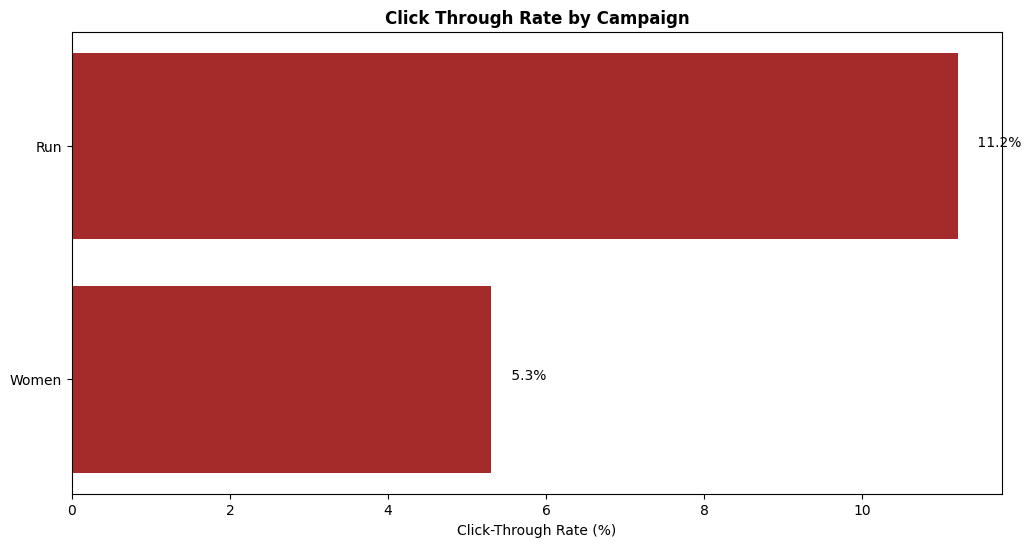

In [20]:

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    q1.sort_values('CTR').index,
    q1.sort_values('CTR')['CTR'],
    color = ['brown' if winner else 'green' in q1.sort_values('CTR').index])

for bar, val in zip(bars, q1.sort_values('CTR')['CTR']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f"{val: .1f}%")

ax.set_xlabel('Click-Through Rate (%)')
ax.set_title('Click Through Rate by Campaign', fontweight = 'bold')

plt.savefig('CTR_by_Campaign.png')
plt.show()
plt.close()



### 2. Which country has the highest conversion rate?

In [21]:
marketing = pd.read_csv(r"C:\Users\LENOVO YOGA X390\Desktop\PyData_Capstone_Project\cleaned_Round2_TaskforGeneration.csv")

In [22]:
print(marketing.columns.tolist())

['Unnamed: 0', 'Date', 'Campaign Code', 'Campaign Name', 'PO Number', 'Channel', 'Country Code', 'Tactic', 'Media Cost', 'Impressions', 'Conversions', 'Clicks', 'Month', 'Campaign Mode']


Conversion Rate by Country
              total_conversions  total_clicks   CVR
Country Code                                       
UK                       149381       2360955  6.33
DE                       136853       3113799  4.40
Insight: UK has the highest conversion rate at 6.33%.
Out of every 100 clicks in UK, about 6 resulted in a conversion.
DE converts at 4.40%, which is 1.93 percentage points lower.


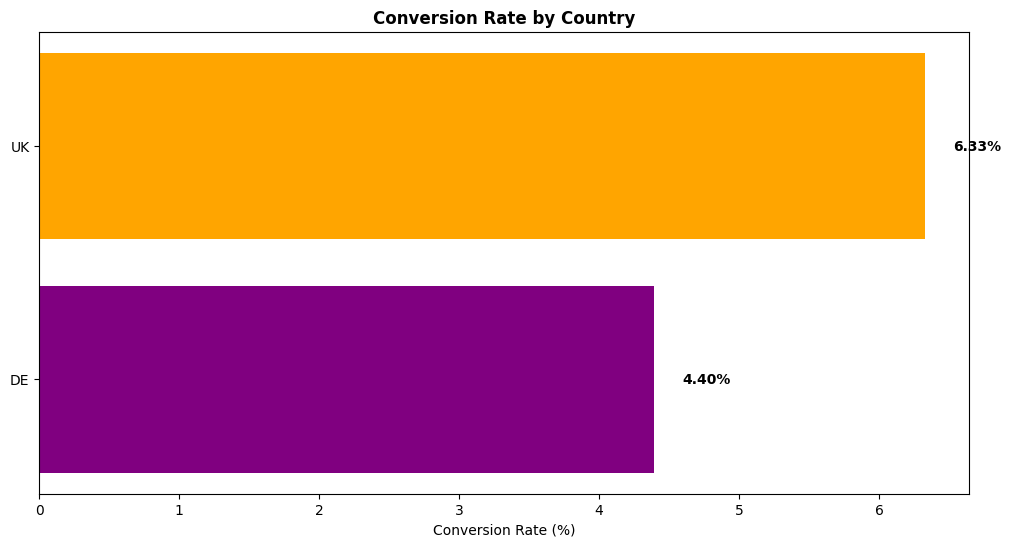

In [23]:
# Groupby country and calculate totals
q2 = marketing.groupby('Country Code').agg(
    total_conversions = ('Conversions', 'sum'),
    total_clicks = ('Clicks', 'sum')
)

#Calculate conversion Rate
q2['CVR'] = q2['total_conversions'] / q2['total_clicks'] * 100

# Sort by conversion rate
q2 = q2.sort_values( 'CVR', ascending= False)

#Best and worst performers
winner_q2 = q2['CVR'].idxmax()
loser_q2 = q2['CVR'].idxmin()

#Output

print("="*50)
print("Conversion Rate by Country")
print("="*50)

print(q2[['total_conversions', 'total_clicks', 'CVR']].round(2).to_string())

print(f"""Insight: {winner_q2} has the highest conversion rate at {q2.loc[winner_q2,'CVR']:.2f}%.
Out of every 100 clicks in {winner_q2}, about {q2.loc[winner_q2,'CVR']:.0f} resulted in a conversion.
{loser_q2} converts at {q2.loc[loser_q2,'CVR']:.2f}%, which is {q2.loc[winner_q2,'CVR'] - q2.loc[loser_q2,'CVR']:.2f} percentage points lower.""")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sorted_q2 = q2.sort_values('CVR')
bar_colors = ['orange' if country == winner_q2 else 'purple' for country in sorted_q2.index] 

bars = ax.barh(
    sorted_q2.index,
    sorted_q2['CVR'],
    color= bar_colors)
 
# Add value labels
for bar, val in zip(bars, sorted_q2['CVR']):
            ax.text(val+0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}%", fontweight='bold', va='center')
 
ax.set_xlabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Country", fontweight='bold')
 
plt.savefig('q2_cvr_by_country.png')
plt.show()

### Question 3: During which period do we observe the most conversions?

In [24]:
marketing = pd.read_csv(r"C:\Users\LENOVO YOGA X390\Desktop\PyData_Capstone_Project\cleaned_Round2_TaskforGeneration.csv")

In [25]:
marketing.head()

,Unnamed: 0,Date,Campaign Code,Campaign Name,PO Number,Channel,Country Code,Tactic,Media Cost,Impressions,Conversions,Clicks,Month,Campaign Mode
0,0,2022-01-01,FW20,Run,PO203366,FB,DE,Consideration,441.17,53964,560,2364,2022-01,FW20
1,1,2022-01-02,FW20,Run,PO559150,FB,DE,Consideration,445.27,60733,521,2325,2022-01,FW20
2,2,2022-01-03,FW20,Run,PO424678,FB,DE,Awareness,324.52,68995,76,9128,2022-01,FW20
3,3,2022-01-04,FW20,Run,PO756200,FB,DE,Awareness,412.02,96521,129,12071,2022-01,FW20
4,4,2022-01-05,FW20,Run,PO456943,FB,DE,Conversion,911.34,171899,534,4040,2022-01,FW20


In [26]:
print(marketing['Conversions'].dtype)

int64


In [27]:
print(marketing.shape)

(516, 14)


In [28]:
from calendar import month


In [29]:

monthly = marketing.groupby('Month')['Conversions'].sum()
peak_month = monthly.idxmax()
peak_p = list(monthly.index).index(peak_month)
labels = [str(m) for m in monthly.index]
vals = monthly.values

print("="*50)
print("Monthly Conversions")
print("="*50)
print(monthly.to_string())
print(f"Conversions peaked in {peak_month} with {monthly[peak_month]:,} conversions")
peak_month = monthly.idxmax()
peak_p = list(monthly.index).index(peak_month)
labels = [str(m) for m in monthly.index]
vals = monthly.values


print("="*50)
print("Monthly Conversions")
print("="*50)
print(monthly.to_string())
print(f"Conversions peaked in {peak_month} with {monthly[peak_month]:,} conversions")

Monthly Conversions
Month
2022-01    27830
2022-02    31330
2022-03    22734
2022-04    19583
2022-05    20831
2022-06    27645
2022-07    19683
2022-08    14719
2022-09    14556
2022-10    14397
2022-11    11933
2022-12    13599
2023-01    12438
2023-02     8025
2023-03    10443
2023-04     9067
2023-05     7421
Conversions peaked in 2022-02 with 31,330 conversions
Monthly Conversions
Month
2022-01    27830
2022-02    31330
2022-03    22734
2022-04    19583
2022-05    20831
2022-06    27645
2022-07    19683
2022-08    14719
2022-09    14556
2022-10    14397
2022-11    11933
2022-12    13599
2023-01    12438
2023-02     8025
2023-03    10443
2023-04     9067
2023-05     7421
Conversions peaked in 2022-02 with 31,330 conversions


- Conversions have been declining steadily through 2023.

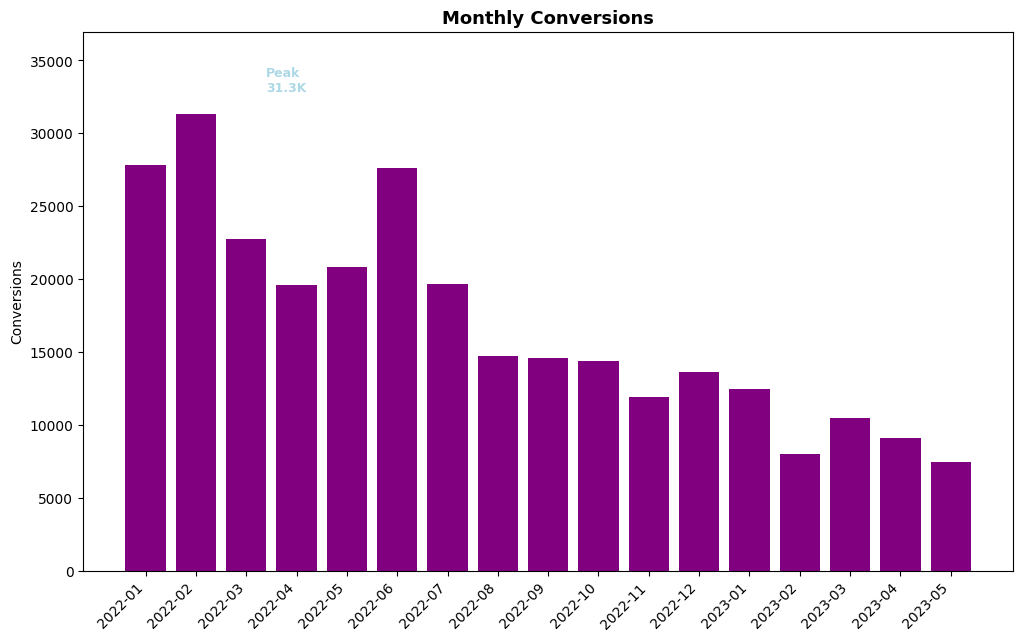

In [30]:
fig, ax = plt.subplots(figsize=(12, 7))

 
bar_colors = ['green' if i == peak_p else 'black' for i in range(len(vals))]
bars = ax.bar(range(len(labels)), vals, color='purple')
 
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel("Conversions", fontsize=10)
ax.set_title("Monthly Conversions", fontsize=13, fontweight='bold')
ax.set_ylim(0, max(vals) * 1.18)
ax.annotate(f'Peak\n{monthly[peak_month]/1000:.1f}K',
            xy=(peak_p, vals[peak_p]),
            xytext=(peak_p + 1.4, vals[peak_p] * 1.05),
            color='lightblue', fontsize=9, fontweight='bold')
 

plt.savefig('q3_monthly_conversions.png')
plt.show()
plt.close()

### Question 4: What % change in conversions is observed month over month?

In [31]:
marketing = pd.read_csv(r"C:\Users\LENOVO YOGA X390\Desktop\PyData_Capstone_Project\cleaned_Round2_TaskforGeneration.csv")

Month over Month % Change in Conversions
Month
2022-01      NaN
2022-02    12.58
2022-03   -27.44
2022-04   -13.86
2022-05     6.37
2022-06    32.71
2022-07   -28.80
2022-08   -25.22
2022-09    -1.11
2022-10    -1.09
2022-11   -17.11
2022-12    13.96
2023-01    -8.54
2023-02   -35.48
2023-03    30.13
2023-04   -13.18
2023-05   -18.15
The strongest growth month was 2022-06 (+32.7%)
The steepest decline month was 2023-02 (-35.5%)


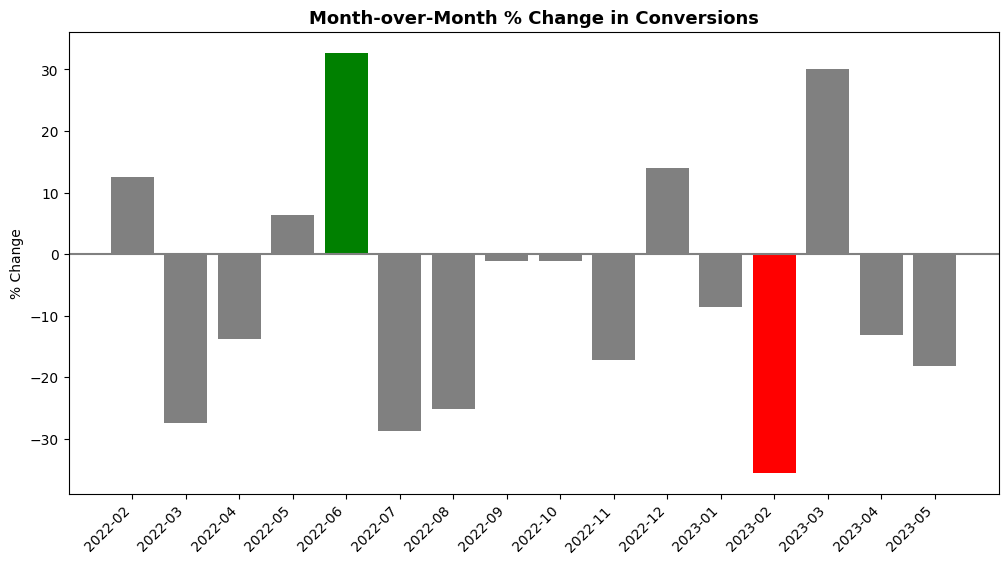

In [32]:
monthly = marketing.groupby('Month')['Conversions'].sum()

# MoM % change
mom = monthly.pct_change() * 100
mom_clean= mom.dropna()

#Plotting values
mom_vals =mom_clean.values
mom_labels = mom_clean.index

print("=" *50)
print("Month over Month % Change in Conversions")
print("="*50)
print(mom.round(2).to_string())
print(f"The strongest growth month was {mom_clean.idxmax()} ({mom_clean.max():+.1f}%)")
      
print(f"The steepest decline month was {mom_clean.idxmin()} ({mom_clean.min():+.1f}%)")

# figure

fig, ax = plt.subplots(figsize=(12, 6))
 
bar_colors = ['gray' if v >= 0 else 'gray' for v in mom_vals]

#Highlight best and worst
max_idx = np.argmax(mom_vals)
min_idx = np.argmin(mom_vals)

bar_colors[max_idx] = 'green'
bar_colors[min_idx] = 'red'
bars = ax.bar(range(len(mom_labels)), mom_vals, color=bar_colors)

ax.axhline(0,color='gray')

ax.set_xticks(range(len(mom_labels)))
ax.set_xticklabels(mom_labels, ha= 'right', rotation =45)

ax.set_title("Month-over-Month % Change in Conversions",
             color='black', fontsize=13, fontweight='bold')
ax.set_ylabel('% Change')

plt.savefig('month_over_month.png')
plt.show()

### Question 5. How does the marketing funnel (Tactic) perform in terms of Conversions

In [33]:
marketing = pd.read_csv(r"C:\Users\LENOVO YOGA X390\Desktop\PyData_Capstone_Project\cleaned_Round2_TaskforGeneration.csv")

In [34]:
q5 = (
    marketing.groupby('Tactic')
    .agg(
        Impressions = ('Impressions', 'sum'),
        Clicks = ('Clicks', 'sum'),
        Conversions = ('Conversions', 'sum')
    )    
    .reindex(['Awareness', 'Consideration', 'Conversion']))

q5['CTR'] = q5['Clicks'] / q5['Impressions'] * 100
q5['CVR'] = q5['Conversions'] / q5['Clicks'] * 100
best_cvr = q5['CVR'].idxmax()

print("="*50)
print("Funnel Performance by Tactic")
print("="*50)
print(q5[['Impressions', 'Clicks', 'Conversions', 'CTR', 'CVR']].round(2).to_string())
print(f"""
The '{best_cvr}' tactic has the highest conversion rate at {q5.loc[best_cvr, 'CVR']:.1f}%,
indicating it is the most effective at converting clicks into conversions. 
""")

Funnel Performance by Tactic
               Impressions   Clicks  Conversions    CTR    CVR
Tactic                                                        
Awareness         25778815  4060015        20566  15.75   0.51
Consideration     11641976   496063       107521   4.26  21.67
Conversion        17594637   918676       158147   5.22  17.21

The 'Consideration' tactic has the highest conversion rate at 21.7%,
indicating it is the most effective at converting clicks into conversions. 



Funnel Performance by Tactic
               Impressions   Clicks  Conversions    CTR    CVR
Tactic                                                        
Awareness         25778815  4060015        20566  15.75   0.51
Consideration     11641976   496063       107521   4.26  21.67
Conversion        17594637   918676       158147   5.22  17.21

The 'Consideration' tactic has the highest conversion rate at 21.7%,
indicating it is the most effective at converting clicks into conversions.

`Awareness` reaches the widest audience (25.8M impressions) 
but has the lowest CVR (0.51%) 



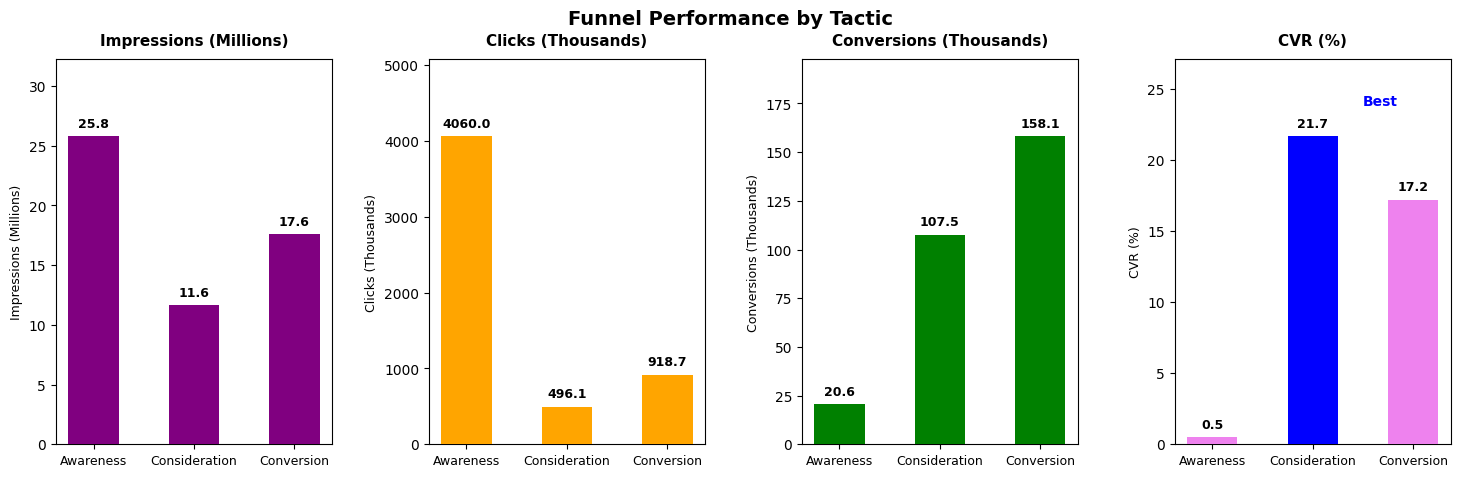

In [38]:
# reindex forces the logical funnel order: Awareness → Consideration → Conversion
# CTR = Clicks / Impressions × 100  (engagement rate)
# CVR = Conversions / Clicks × 100  (conversion efficiency)
# Chart has 4 panels: Impressions, Clicks, Conversions (volume) + CVR (efficiency)
# CVR panel highlights the winner so the insight from the print output is visible

# Metrics by tactic
q5 = (
    marketing.groupby('Tactic')
    .agg(
        Impressions = ('Impressions', 'sum'),
        Clicks = ('Clicks', 'sum'),
        Conversions = ('Conversions', 'sum')
    )    
    .reindex(['Awareness', 'Consideration', 'Conversion']))

# 
q5['CTR'] = q5['Clicks'] / q5['Impressions'] * 100
q5['CVR'] = q5['Conversions'] / q5['Clicks'] * 100
best_cvr = q5['CVR'].idxmax()

print("="*50)
print("Funnel Performance by Tactic")
print("="*50)
print(q5[['Impressions', 'Clicks', 'Conversions', 'CTR', 'CVR']].round(2).to_string())
print(f"""
The '{best_cvr}' tactic has the highest conversion rate at {q5.loc[best_cvr, 'CVR']:.1f}%,
indicating it is the most effective at converting clicks into conversions.

`Awareness` reaches the widest audience ({q5.loc['Awareness', 'Impressions']/ 1e6:.1f}M impressions) 
but has the lowest CVR ({q5.loc['Awareness', 'CVR']:.2f}%) 
""")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.subplots_adjust(wspace= 0.35)
fig.suptitle('Funnel Performance by Tactic',
             color='black', fontsize=14, fontweight='bold')
 
for ax, col, color, unit, scale in zip(
    axes,
    ['Impressions', 'Clicks', 'Conversions', 'CVR'],
    ['purple',        'orange',    'green',         'blue'],
    ['Millions',           'Thousands',       'Thousands',           '%'],
    [1e6,           1e3,       1e3,           1]
):
 
    vals = q5[col] / scale
 
    # highlight the CVR winner, dim the others
    if col == 'CVR':
        bar_colors = [color if t == best_cvr else 'violet' for t in q5.index]
    else:
        bar_colors = color
 
    bars = ax.bar(q5.index, vals, color=bar_colors, width=0.5, zorder=3)
 
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + vals.max() * 0.02,
                f'{val:.1f}',
                ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')
 
    ax.set_title(f'{col} ({unit})', color='black', fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel(f'{col} ({unit})', fontsize=9)
    ax.set_ylim(0, vals.max() * 1.25)
    ax.set_xticks(range(len(q5.index)))
    ax.set_xticklabels(q5.index, fontsize=9)
 
    # annotate the best CVR bar
    if col == 'CVR':
        best_i = list(q5.index).index(best_cvr)
        ax.annotate('Best',
                    xy=(best_i, vals[best_cvr]),
                    xytext=(best_i + 0.5, vals[best_cvr] * 1.1),
                    color='blue', fontweight='bold')

plt.savefig('q5_funnel_by_tactic.png')
plt.show()
plt.close()